# Prediccion de redshift con XGBoost

Se predice el redshift espectroscopico a partir de features fotometricas del catalogo DESI Legacy Imaging Survey.

Estructura del notebook:
1. Ingenieria de features (magnitudes corregidas, colores)
2. Split train/val/test 60/20/20, con test reservado hasta el final
3. Modelo dummy como baseline
4. XGBoost con hiperparametros por defecto
5. Optimizacion de hiperparametros (Optuna, CV sobre train)
6. PFI sobre modelo optimizado para seleccionar features
7. Re-entrenamiento con features seleccionadas
8. Evaluacion final en test

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().resolve().parent))
from preprocess_vae import load_features

from sklearn.dummy import DummyRegressor
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from xgboost import XGBRegressor

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

/home/nacho/Projects/AS4501-Proyect/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = load_features()

# Magnitudes WISE corregidas por extincion galactica
bands_wise = ["w1", "w2", "w3", "w4"]
for band in bands_wise:
    df["flux_" + band + "_corr"] = df["flux_" + band] / df["mw_transmission_" + band]
    df["mag_" + band + "_corr"] = 22.5 - 2.5 * np.log10(df["flux_" + band + "_corr"])

# Flujos de apertura corregidos y magnitudes (bandas opticas)
bands_optical = ["g", "r", "i", "z"]
for band in bands_optical:
    trans = df[f'mw_transmission_{band}']
    apcols = [c for c in df.columns if c.startswith(f'apflux_{band}_')]
    for col in apcols:
        flux_corr = df[col] / trans
        df[f'{col}_corr'] = flux_corr
        mag_col = col.replace('apflux', 'mag')
        df[mag_col] = 22.5 - 2.5 * np.log10(flux_corr.where(flux_corr > 0))

# Seleccion de columnas: morfologia + magnitudes + redshift
mag_cols = [c for c in df.columns if c.startswith('mag_')]
df = df[['type', 'shape_r', 'shape_e1', 'shape_e2', 'sersic', 'z'] + mag_cols].copy()
df = df.dropna()

X = df.drop(columns=['z']).copy()
y = df['z'].copy()

# Colores a partir de magnitudes corregidas
color_pairs = [
    ("g", "i"), ("g", "r"), ("r", "i"), ("i", "z"),
    ("z", "w1"), ("w1", "w2"), ("w2", "w3"), ("w3", "w4"),
]
for b1, b2 in color_pairs:
    X[f"color_{b1}{b2}"] = X[f"mag_{b1}_corr"] - X[f"mag_{b2}_corr"]

print(f"Features: {X.shape[1]}, Objetos: {X.shape[0]}")
X.columns.tolist()

Filtros de catálogo:
  inicial            : 29575
  maskbits==0        : 27757
  flujo>0 (griz)     : 26166
  profundidad (mag)  : 21340
  SNR>=3 (griz)      : 21287
Features: 45, Objetos: 6790


/home/nacho/Projects/AS4501-Proyect/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


['type',
 'shape_r',
 'shape_e1',
 'shape_e2',
 'sersic',
 'mag_g_corr',
 'mag_r_corr',
 'mag_i_corr',
 'mag_z_corr',
 'mag_w1_corr',
 'mag_w2_corr',
 'mag_w3_corr',
 'mag_w4_corr',
 'mag_g_0_5',
 'mag_g_0_75',
 'mag_g_1_0',
 'mag_g_1_5',
 'mag_g_2_0',
 'mag_g_3_5',
 'mag_r_0_5',
 'mag_r_0_75',
 'mag_r_1_0',
 'mag_r_1_5',
 'mag_r_2_0',
 'mag_r_3_5',
 'mag_i_0_5',
 'mag_i_0_75',
 'mag_i_1_0',
 'mag_i_1_5',
 'mag_i_2_0',
 'mag_i_3_5',
 'mag_z_0_5',
 'mag_z_0_75',
 'mag_z_1_0',
 'mag_z_1_5',
 'mag_z_2_0',
 'mag_z_3_5',
 'color_gi',
 'color_gr',
 'color_ri',
 'color_iz',
 'color_zw1',
 'color_w1w2',
 'color_w2w3',
 'color_w3w4']

## Funciones de evaluacion

In [3]:
def evaluate_regression(y_true, y_pred, label, threshold=0.05):
    """Metricas estandar de regresion + metricas de photo-z."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    delta_z = (y_pred - y_true) / (1 + y_true)
    bias = delta_z.mean()
    std_dz = delta_z.std()
    sigma_mad = 1.4826 * np.median(np.abs(delta_z - np.median(delta_z)))
    eta = (np.abs(delta_z) > threshold).mean() * 100

    print(f"--- {label} ---")
    print(f"MAE:       {mae:.5f}")
    print(f"MSE:       {mse:.5f}")
    print(f"RMSE:      {rmse:.5f}")
    print(f"R2:        {r2:.5f}")
    print(f"bias(dz):  {bias:.5f}")
    print(f"std(dz):   {std_dz:.5f}")
    print(f"sigma_MAD: {sigma_mad:.5f}")
    print(f"eta [%]:   {eta:.3f}")
    print()

    return {
        "MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2,
        "bias": bias, "std_dz": std_dz, "sigma_MAD": sigma_mad, "eta": eta,
    }


def plot_specz_vs_photoz(z_true, z_pred, threshold=0.05, title=None, ax=None):
    """Scatter z_spec vs z_phot con linea 1:1 y limites de error catastrofico."""
    z_true = np.asarray(z_true, dtype=float)
    z_pred = np.asarray(z_pred, dtype=float)

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 8))

    ax.scatter(z_true, z_pred, alpha=0.4, s=4)

    lo = min(z_true.min(), z_pred.min())
    hi = max(z_true.max(), z_pred.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=2, label="1:1")

    z_line = np.linspace(lo, hi, 200)
    ax.plot(z_line, z_line + threshold * (1 + z_line), color="red", lw=2, label=f"Limite catastrofico (|dz| > {threshold})")
    ax.plot(z_line, z_line - threshold * (1 + z_line), color="red", lw=2)

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel("Redshift espectroscopico")
    ax.set_ylabel("Redshift fotometrico predicho")
    if title:
        ax.set_title(title)
    ax.legend(loc="upper left", fontsize=8)
    return ax

## Split train / val / test (60 / 20 / 20)

El conjunto de test no se toca hasta tener el modelo final.

In [4]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=124
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=124
)
# 0.25 de 80% = 20% del total

print(f"Train: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val:   {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test:  {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

numeric_features = [c for c in X.columns if c != "type"]
categorical_features = ["type"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), categorical_features),
    ]
)

Train: 4074 (60.0%)
Val:   1358 (20.0%)
Test:  1358 (20.0%)


## Modelo baseline y XGBoost por defecto

Primero se evalua un dummy como piso de rendimiento y luego un XGBoost con hiperparametros razonables por defecto.

--- Dummy (media) ---
MAE:       0.29743
MSE:       0.13197
RMSE:      0.36328
R2:        -0.00034
bias(dz):  0.04802
std(dz):   0.21881
sigma_MAD: 0.24110
eta [%]:   90.574

--- XGB default ---
MAE:       0.05809
MSE:       0.01356
RMSE:      0.11643
R2:        0.89724
bias(dz):  0.00421
std(dz):   0.07687
sigma_MAD: 0.03181
eta [%]:   18.041



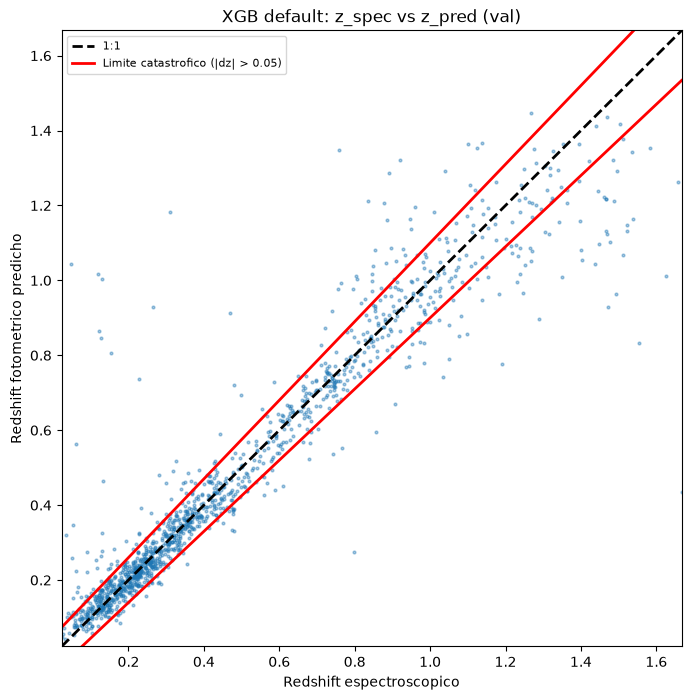

In [5]:
results = {}

dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_val)

results["Dummy (media)"] = evaluate_regression(
    y_val.to_numpy(), y_pred_dummy, "Dummy (media)"
)

xgb_default = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=1,
        gamma=0.0,
        reg_alpha=0.0,
        reg_lambda=1.0,
        objective="reg:squarederror",
        eval_metric="rmse",
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    ))
])

xgb_default.fit(X_train, y_train)
y_pred_default = xgb_default.predict(X_val)

results["XGB default"] = evaluate_regression(
    y_val.to_numpy(), y_pred_default, "XGB default"
)

plot_specz_vs_photoz(
    y_val.to_numpy(), y_pred_default,
    title="XGB default: z_spec vs z_pred (val)"
)
plt.show()

## Optimizacion de hiperparametros con Optuna

Se usa cross-validation de 5 folds solo sobre el conjunto de train. El conjunto de validacion se usa despues para evaluar y calcular PFI.

Best trial: 31. Best value: 0.0104567: 100%|██████████| 50/50 [00:58<00:00,  1.17s/it]


Mejor MSE (CV): 0.010457
Mejores hiperparametros: {'n_estimators': 706, 'max_depth': 10, 'learning_rate': 0.021815743387957363, 'subsample': 0.9880183788272353, 'colsample_bytree': 0.8541274299679549, 'min_child_weight': 5.903356718694068, 'gamma': 0.008932181016837439, 'reg_alpha': 0.028564990655015433, 'reg_lambda': 0.8291567417755946}
--- XGB optimizado ---
MAE:       0.05952
MSE:       0.01393
RMSE:      0.11801
R2:        0.89444
bias(dz):  0.00450
std(dz):   0.07802
sigma_MAD: 0.03226
eta [%]:   19.293



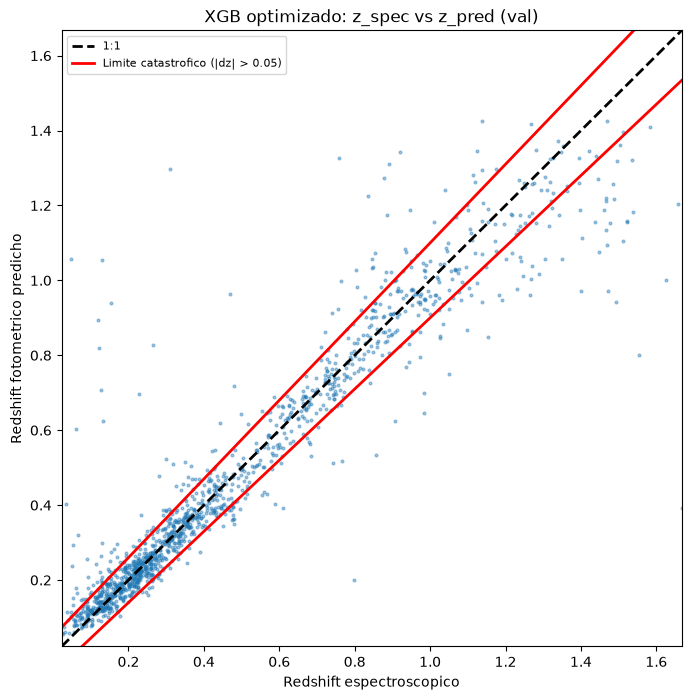

In [6]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1200),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 10.0),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 100.0, log=True),
    }

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", XGBRegressor(
            **params,
            objective="reg:squarederror",
            eval_metric="rmse",
            tree_method="hist",
            random_state=42,
            n_jobs=1,
            verbosity=0,
        ))
    ])

    scores = cross_val_score(
        pipe, X_train, y_train,
        scoring="neg_mean_squared_error",
        cv=5,
        n_jobs=-1,
    )
    return -scores.mean()


study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

best_params = study.best_params
print(f"Mejor MSE (CV): {study.best_value:.6f}")
print(f"Mejores hiperparametros: {best_params}")

xgb_opt = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(
        **best_params,
        objective="reg:squarederror",
        eval_metric="rmse",
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    ))
])

xgb_opt.fit(X_train, y_train)
y_pred_opt = xgb_opt.predict(X_val)

results["XGB optimizado"] = evaluate_regression(
    y_val.to_numpy(), y_pred_opt, "XGB optimizado"
)

plot_specz_vs_photoz(
    y_val.to_numpy(), y_pred_opt,
    title="XGB optimizado: z_spec vs z_pred (val)"
)
plt.show()

## Interpretabilidad: MDI y PFI sobre modelo optimizado

PFI se calcula sobre el conjunto de validacion, no sobre test.

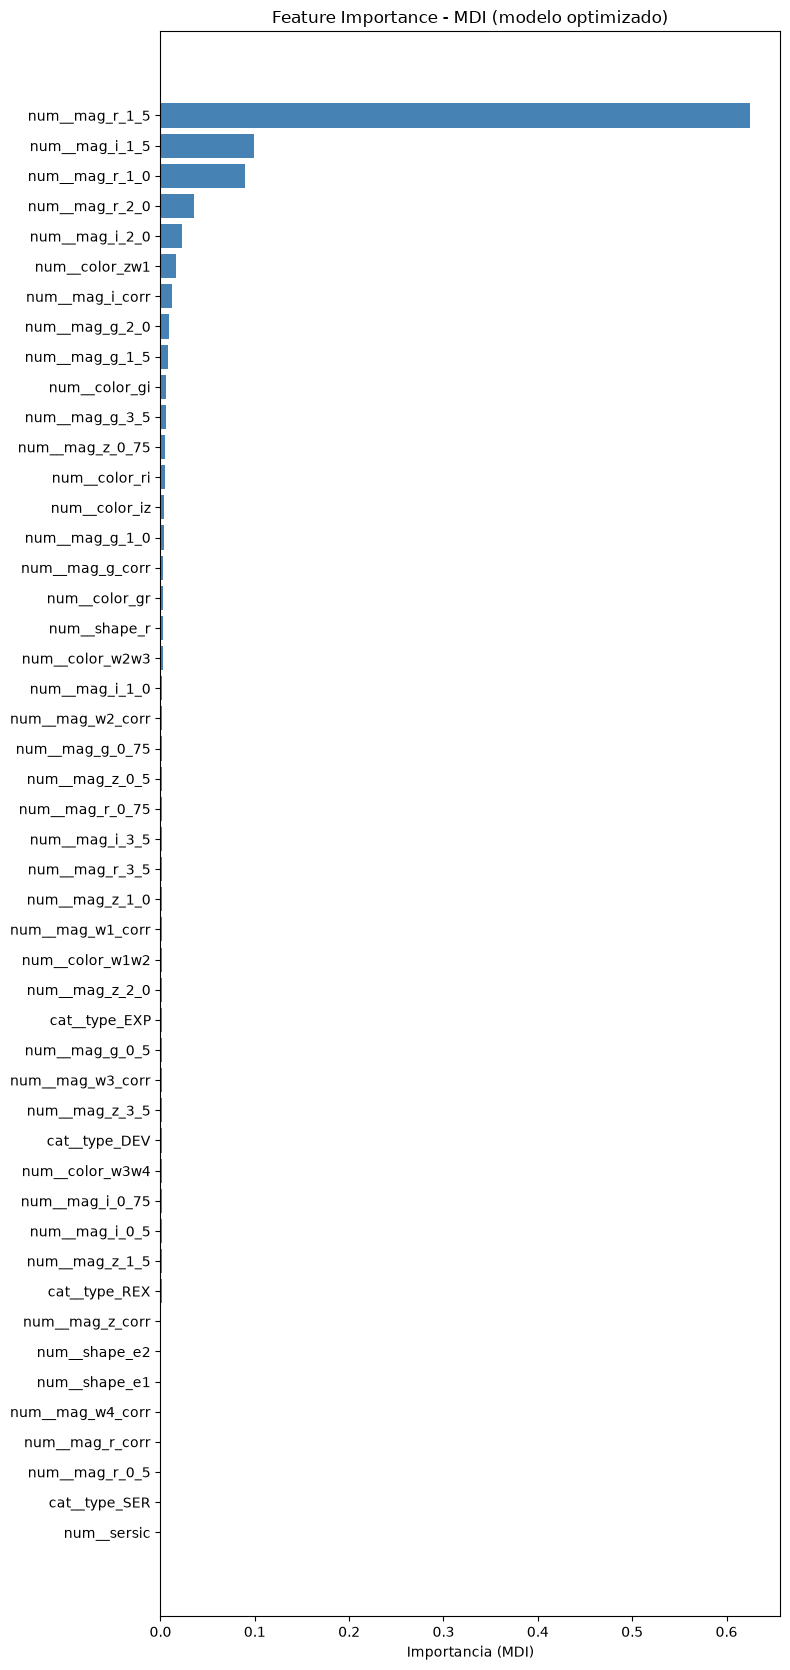

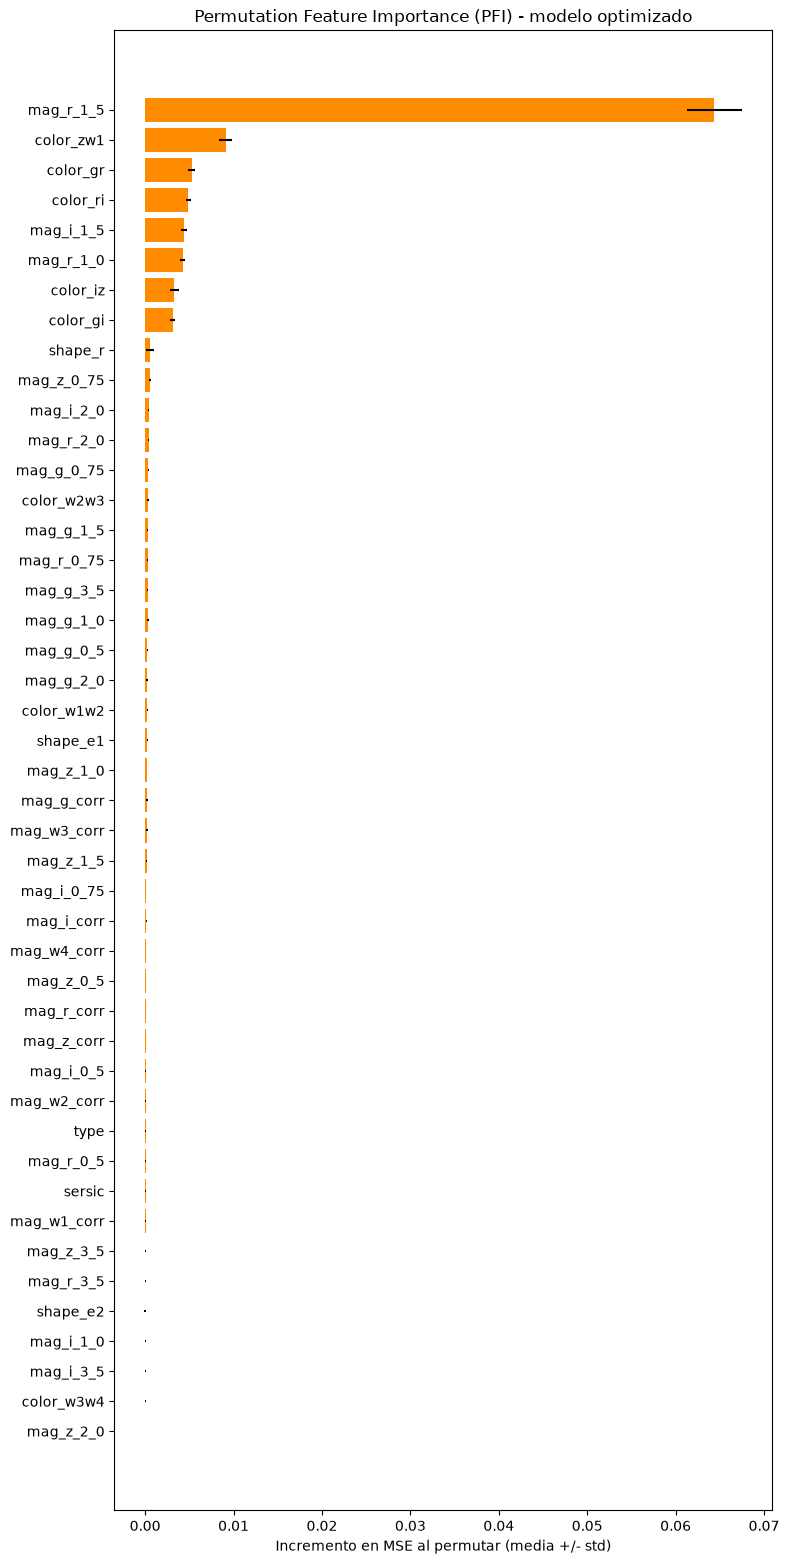

,feature,importance_mean,importance_std
22,mag_r_1_5,0.064384,0.003119
41,color_zw1,0.009105,0.000729
38,color_gr,0.005273,0.000381
39,color_ri,0.004879,0.000291
28,mag_i_1_5,0.004405,0.000322
21,mag_r_1_0,0.004224,0.000318
40,color_iz,0.003287,0.000532
37,color_gi,0.003099,0.000293
1,shape_r,0.000576,0.000434
32,mag_z_0_75,0.000566,0.000144


In [7]:
# Feature importance por Mean Decrease in Impurity (MDI)
feature_names_out = xgb_opt.named_steps["preprocessor"].get_feature_names_out()
importances_mdi = xgb_opt.named_steps["regressor"].feature_importances_

imp_mdi_df = pd.DataFrame({
    "feature": feature_names_out,
    "importance": importances_mdi
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, max(4, 0.35 * len(imp_mdi_df))))
plt.barh(imp_mdi_df["feature"], imp_mdi_df["importance"], color="steelblue")
plt.gca().invert_yaxis()
plt.xlabel("Importancia (MDI)")
plt.title("Feature Importance - MDI (modelo optimizado)")
plt.tight_layout()
plt.show()

# Permutation Feature Importance (PFI) sobre conjunto de validacion
pfi_result = permutation_importance(
    xgb_opt,
    X_val,
    y_val,
    scoring="neg_mean_squared_error",
    n_repeats=30,
    random_state=42,
    n_jobs=-1,
)

pfi_df = pd.DataFrame({
    "feature": X_val.columns,
    "importance_mean": pfi_result.importances_mean,
    "importance_std": pfi_result.importances_std,
}).sort_values("importance_mean", ascending=False)

plt.figure(figsize=(8, max(4, 0.35 * len(pfi_df))))
plt.barh(
    pfi_df["feature"],
    pfi_df["importance_mean"],
    xerr=pfi_df["importance_std"],
    color="darkorange",
)
plt.gca().invert_yaxis()
plt.xlabel("Incremento en MSE al permutar (media +/- std)")
plt.title("Permutation Feature Importance (PFI) - modelo optimizado")
plt.tight_layout()
plt.show()

pfi_df

## Seleccion de features y re-entrenamiento

Se descartan features con PFI negativa o nula (permutar la feature no empeora el modelo, lo que indica que no aporta informacion util).

Features seleccionadas: 44 de 45
Features descartadas: ['mag_z_2_0']
--- XGB optimizado + features PFI ---
MAE:       0.05991
MSE:       0.01408
RMSE:      0.11865
R2:        0.89329
bias(dz):  0.00437
std(dz):   0.07800
sigma_MAD: 0.03303
eta [%]:   20.177



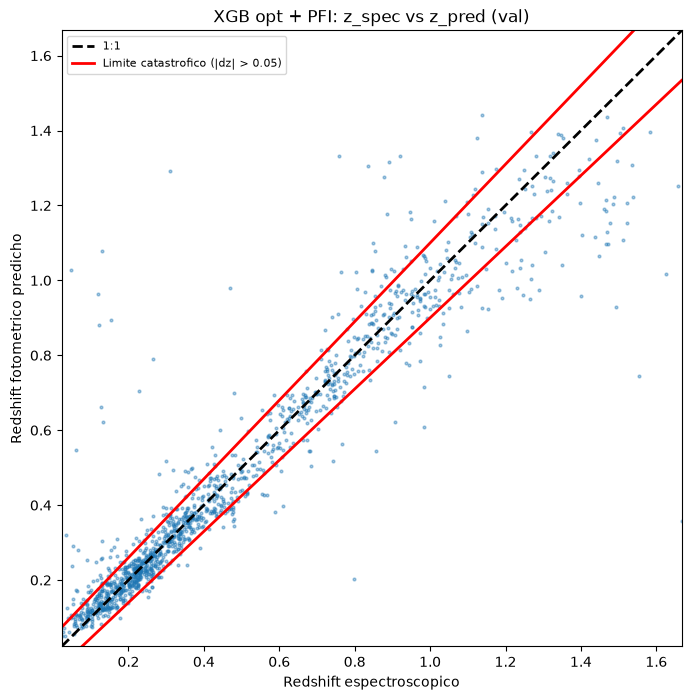

,MAE,MSE,RMSE,R2,bias,std_dz,sigma_MAD,eta
Dummy (media),0.297433,0.131970,0.363277,-0.000342,0.048023,0.218808,0.241102,90.574374
XGB default,0.058089,0.013556,0.116432,0.897242,0.004208,0.076872,0.031809,18.041237
XGB optimizado,0.059517,0.013926,0.118009,0.894438,0.004499,0.078017,0.032262,19.293078
XGB opt + PFI,0.059907,0.014078,0.118649,0.893291,0.004367,0.077996,0.033030,20.176730


In [8]:
# Features con PFI positiva
selected_features = pfi_df[pfi_df["importance_mean"] > 0]["feature"].tolist()
if not selected_features:
    selected_features = X.columns.tolist()
    print("PFI positiva vacia; se conservan todas las features para no romper el pipeline.")

dropped = [f for f in X.columns if f not in selected_features]
print(f"Features seleccionadas: {len(selected_features)} de {X.shape[1]}")
print(f"Features descartadas: {dropped}")

# Reconstruir preprocessor con las features seleccionadas
num_selected = [c for c in selected_features if c != "type"]
cat_selected = [c for c in selected_features if c == "type"]

transformers_sel = []
if num_selected:
    transformers_sel.append(("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), num_selected))
if cat_selected:
    transformers_sel.append(("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), cat_selected))

preprocessor_sel = ColumnTransformer(transformers=transformers_sel)

xgb_selected = Pipeline([
    ("preprocessor", preprocessor_sel),
    ("regressor", XGBRegressor(
        **best_params,
        objective="reg:squarederror",
        eval_metric="rmse",
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    ))
])

xgb_selected.fit(X_train[selected_features], y_train)
y_pred_sel = xgb_selected.predict(X_val[selected_features])

results["XGB opt + PFI"] = evaluate_regression(
    y_val.to_numpy(), y_pred_sel, "XGB optimizado + features PFI"
)

plot_specz_vs_photoz(
    y_val.to_numpy(), y_pred_sel,
    title="XGB opt + PFI: z_spec vs z_pred (val)"
)
plt.show()

comparison = pd.DataFrame(results).T
comparison

## Evaluacion final en test

Ejecutar solo cuando el modelo este definido. Elegir el mejor modelo segun la tabla anterior y evaluarlo en test una sola vez.

--- Modelo final (test) ---
MAE:       0.05523
MSE:       0.01362
RMSE:      0.11671
R2:        0.89280
bias(dz):  0.00282
std(dz):   0.06752
sigma_MAD: 0.03026
eta [%]:   17.452



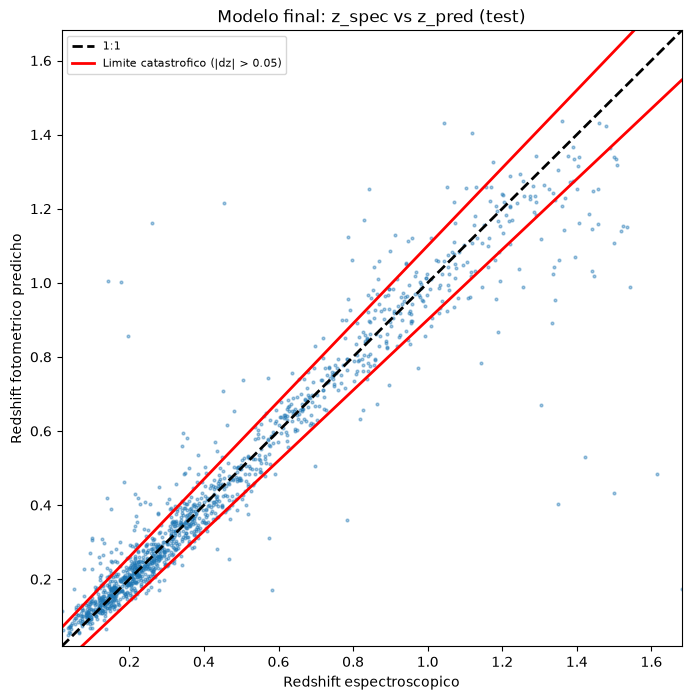

In [9]:
# Elegir el modelo final (cambiar segun la comparacion anterior)
# Opcion 1: xgb_opt (todas las features)
# Opcion 2: xgb_selected (features PFI)

final_model = xgb_selected
final_features = selected_features  # None si se usa xgb_opt con todas las features

if final_features is not None:
    y_pred_test = final_model.predict(X_test[final_features])
else:
    y_pred_test = final_model.predict(X_test)

results_test = evaluate_regression(
    y_test.to_numpy(), y_pred_test, "Modelo final (test)"
)

plot_specz_vs_photoz(
    y_test.to_numpy(), y_pred_test,
    title="Modelo final: z_spec vs z_pred (test)"
)
plt.show()